# The Minerals Workforce Pipeline Model
### Can announced federal investments close America's critical minerals workforce gap in time?

**Project FORGE — Industrial Capacity Notebook 01 (v0.2)**
**Author:** Edikan Udofia · **Published:** August 2026

*This model was developed through the author's doctoral research in operations research.
All inputs are cited public figures (VERIFIED) or explicitly flagged assumptions with
sensitivity ranges. Version 0.2 completed the primary-source verification pass; remaining
items for the journal version are listed in the Limitations section.*

---

**The question.** In August 2026, the federal government announced $180 million for mining
education, including a $100 million DOE grant program intended to "dramatically increase" the
number of degree-holders in mining and critical minerals fields within two years, alongside a
$32.7 million technology development hub at the Colorado School of Mines. This notebook asks a
question the announcements do not answer: **given the time lags built into degree production,
can expanded university enrollment arithmetically close the workforce gap on the timeline
national policy requires — and if not, what does the shortfall demand?**

**The method.** A transparent stock-and-flow (cohort pipeline) model of the U.S. minerals
workforce, run at two tiers: (1) the **degreed engineer tier** (mining/mineral engineering
degrees) and (2) the **skilled practitioner tier** (the technician and operator workforce that
constitutes the large majority of replacement demand). All inputs are either VERIFIED public
figures with citations or clearly labeled ASSUMPTIONS with sensitivity ranges.

**Independence note.** This is independent analysis on public data. It is not affiliated with,
funded by, or endorsed by the Department of Energy, the Department of Defense, the Colorado
School of Mines critical minerals hub, or any government program.

## 1. Data layer

### VERIFIED inputs (public, cited)

| # | Quantity | Value | Source |
|---|----------|-------|--------|
| V1 | U.S. mining workers expected to retire by 2029 (">half the current workforce") | ~221,000 | SME, "Workforce Trends in the U.S. Mining Industry" (smenet.org technical briefing); cited by CSIS (Dec 2024) and in Congressional testimony (W. Copan, House Natural Resources, 2023) |
| V2 | Mining & mineral engineering degrees awarded, 2020 | 327 | CSIS, "The United States Needs More than Mining Engineers..." (Dec 2024) |
| V3 | Net drop in U.S. mining/mineral engineering graduations since 2016 | −39% | CSIS (Dec 2024) |
| V4 | U.S. mining/mineral engineering programs, decline | 25 → 14 | SME, "Maintaining the Viability of U.S. Mining Education" (smenet.org technical briefing); CSIS (Dec 2024) reports 15 as of 2023 |
| V5 | Students enrolled in U.S. mining engineering programs, 2023 (vs. ~8 yrs earlier) | <600 (vs. ~1,500) | SME/SOMP data as reported by CBS News (Aug 7, 2026); primary annual series is the SME Guide to Minerals and Materials Science Schools (obtain for journal version) |
| V6 | Mining jobs to fill per year, next two decades (replacement + growth) | 11,000–13,000 | SME (via The Oregon Group; reported by MINING.com, Feb 2024) |
| V7 | U.S. mining sector job vacancies, Apr 2023 (vs. 2022) | 36,000 (vs. 27,000) | SME reporting, MINING.com (Feb 2024) |
| V8 | Federal mining-education package announced Aug 7, 2026 | $100M DOE (PROSPECT, Notice of Intent); ~$81.3M defense package: Mines $32.7M, SD Mines $25M, Johns Hopkins $23.6M | DOE press release, energy.gov (Aug 7, 2026); press reporting (CBS, OANN, Washington Examiner, Aug 7, 2026) |
| V9 | PROSPECT's stated goal (official wording) | "double the number of graduates with degrees related to mining, minerals, and associated supply chain technologies within two years"; eligibility includes universities, community colleges, trade schools, industry partners | DOE press release, energy.gov (Aug 7, 2026) |
| V10 | Geoscience workforce expected to retire by 2029 / projected shortage | 27% / ~130,000 | American Geosciences Institute (via Grist, Feb 2024) |
| V11 | Projected annual openings, mining and geological engineers, 2024-2034 | ~400 per year (mostly replacement) | U.S. Bureau of Labor Statistics, Occupational Outlook Handbook, Mining and Geological Engineers (bls.gov) |

**Verification status:** V1 traced to SME's own briefing page. V2-V3 from CSIS (primary
analysis). V4 traced to SME's own briefing. V8-V9 verified against the DOE press release on
energy.gov (primary source). V11 traced to BLS OOH (primary source). V5 from Aug 7, 2026
press reporting of SME/SOMP data; the SME Guide to Minerals and Materials Science Schools is
the primary annual series and should be obtained for the journal version. V6, V7, V10 are
secondary reports of SME/AGI figures; trace to primary before journal submission.

**A note on V9 that previews the central finding:** PROSPECT's official goal is to double
*graduates* — not enrollment — within two years. Students graduating in 2027–2028 are already
enrolled today, so a four-year degree pipeline cannot double its output on that timeline under
any funding level. The target is achievable only through near-completion students,
certificates, and short-cycle programs — and DOE's own eligibility list (community colleges,
trade schools, industry partners) reflects this. The government's program design implicitly
concedes the arithmetic this notebook makes explicit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ---------------- VERIFIED constants (see table above) ----------------
V = dict(
    retirees_by_2029      = 221_000,   # V1: SME
    degrees_2020          = 327,       # V2: CSIS
    grad_drop_2016_2020   = 0.39,      # V3: CSIS
    enroll_2023           = 600,       # V5: <600; modeled at the bound (conservative)
    enroll_2015           = 1_500,     # V5: "~1,500 eight years earlier"
    jobs_per_year_lo      = 11_000,    # V6: SME
    jobs_per_year_hi      = 13_000,    # V6: SME
)
V['degrees_2016'] = round(V['degrees_2020'] / (1 - V['grad_drop_2016_2020']))  # ≈ 536
print(f"Implied 2016 graduations from V2 & V3: {V['degrees_2016']}")

Implied 2016 graduations from V2 & V3: 536


### ASSUMPTIONS (flagged, with sensitivity ranges)

These are modeling choices, not verified facts. Each is varied in the sensitivity section.

| # | Assumption | Central value | Range | Basis |
|---|-----------|---------------|-------|-------|
| A1 | BS degree production lag (enrollment cohort → graduation) | 4 yr | 4–5 | Standard program length |
| A2 | Completion rate (entering cohort → degree) | 0.70 | 0.60–0.80 | Absorbed by calibration to the 2020 anchor (see below) |
| A3 | Share of graduates entering U.S. minerals industry | 0.80 | 0.65–0.90 | Placeholder; VERIFY (SME salary/placement surveys) |
| A4 | Engineer-tier annual demand | 400/yr | 300–500 | ANCHORED TO V11 (BLS OOH projected openings, 2024-2034); range covers demand growth above BLS's flat-growth projection |
| A5 | Grant-driven enrollment response | Doubling over 2 yrs (2027–2028), then flat | see scenarios | V9's stated policy goal, taken at face value |
| A6 | Accelerated pathway training lag (non-degree practitioner track) | 1.5 yr | 1–2 | Certificate/community-college/industry program norms |
| A7 | Enrollment path 2015→2023 | linear decline 1,500→600, flat after 2023 in baseline | — | Interpolation between V5 endpoints |

**The structural split now rests on primary data:** V11 fixes the degreed-engineer tier at
roughly 400 openings per year, so the practitioner tier is V6 minus V11, roughly
10,600-12,600 per year, or about 97% of total annual need. This replaces the share
assumption used in v0.1. A caveat for the journal version: BLS's ~400 covers the mining and
geological engineer occupation under its own flat-growth projection; announced processing
buildout implies demand above that baseline, which the 300-500 sensitivity range partially
covers and a demand-growth module should treat properly.

In [2]:
A = dict(lag=4, completion=0.70, industry_entry=0.80,
         eng_openings=400,   # A4 anchored to V11 (BLS OOH)
         accel_lag=1.5)

YEARS = np.arange(2015, 2041)

def enrollment_path(scenario):
    '''Annual new-cohort enrollment (proxied by total enrollment level, A7).'''
    e = np.zeros_like(YEARS, dtype=float)
    for i, y in enumerate(YEARS):
        if y <= 2023:
            e[i] = np.interp(y, [2015, 2023], [V['enroll_2015'], V['enroll_2023']])
        else:
            e[i] = V['enroll_2023']
    if scenario == 'S1_grant_doubling':          # A5 / V9 at face value
        for i, y in enumerate(YEARS):
            if y == 2027: e[i] = V['enroll_2023'] * 1.5
            elif y >= 2028: e[i] = V['enroll_2023'] * 2.0
    elif scenario == 'S2_grant_tripling':        # optimistic upper bound
        for i, y in enumerate(YEARS):
            if y == 2027: e[i] = V['enroll_2023'] * 2.0
            elif y >= 2028: e[i] = V['enroll_2023'] * 3.0
    return e

def graduates(enroll, lag=None, completion=None, calibrate=True):
    '''G(t) = k * completion * cohort_share_of_enrollment(t - lag).
    Enrollment level -> entering-cohort size via division by program length
    (steady-state approximation), lagged, discounted by completion, and scaled
    by a single calibration constant k chosen so the model reproduces the
    VERIFIED 2020 graduation count (V2) exactly. k > 1 indicates the degree
    series (V2) covers a somewhat broader population than the enrollment
    series (V5) -- a commensurability gap documented as limitation L0.'''
    lag = lag or A['lag']; completion = completion or A['completion']
    cohort = enroll / A['lag']
    g = np.zeros_like(cohort)
    g[lag:] = cohort[:-lag] * completion
    if calibrate:
        i2020 = np.where(YEARS == 2020)[0][0]
        k = V['degrees_2020'] / g[i2020]
        g = g * k
    return g

# Report the calibration constant once, transparently
_raw = graduates(enrollment_path('S0_baseline'), calibrate=False)
_i = np.where(YEARS == 2020)[0][0]
K_CAL = V['degrees_2020'] / _raw[_i]
print(f"Calibration constant k = {K_CAL:.3f} "
      f"(raw model 2020 output {_raw[_i]:.0f} vs verified {V['degrees_2020']})")

for s in ['S0_baseline', 'S1_grant_doubling', 'S2_grant_tripling']:
    g = graduates(enrollment_path(s))
    i2020, i2030, i2035 = [np.where(YEARS == y)[0][0] for y in (2020, 2030, 2035)]
    print(f"{s:20s} grads 2020={g[i2020]:5.0f}  2030={g[i2030]:5.0f}  2035={g[i2035]:5.0f}")

Calibration constant k = 1.347 (raw model 2020 output 243 vs verified 327)
S0_baseline          grads 2020=  327  2030=  141  2035=  141
S1_grant_doubling    grads 2020=  327  2030=  141  2035=  283
S2_grant_tripling    grads 2020=  327  2030=  141  2035=  424


**Anchor check and calibration.** The raw pipeline under-predicts the verified 2020 count
(243 modeled vs. 327 verified), implying the CSIS degree series covers a somewhat broader
population than the SME/SOMP enrollment series. Rather than silently tuning parameters, the
model applies one transparent calibration constant (k ≈ 1.35) so 2020 output matches V2
exactly; the commensurability gap is logged as limitation L0 and must be resolved with a
unified primary dataset (ASEE/IPEDS) for the journal version. All scenario *comparisons* are
unaffected, since k scales every scenario identically.

## 2. The demand side

Total replacement + growth demand is V6: 11,000–13,000 jobs/yr. A4 splits this into the
degreed-engineer tier and the practitioner tier. Demand is held constant across scenarios —
deliberately conservative, since announced processing buildout (the $12B stockpile program,
new domestic processing facilities, the Mines hub's commercialization mission) implies demand
growth, not stasis.

In [3]:
demand = {}
for name, total in [('lo', V['jobs_per_year_lo']), ('hi', V['jobs_per_year_hi'])]:
    demand[name] = dict(total=total,
                        engineer=A['eng_openings'],              # V11: BLS OOH openings
                        practitioner=total - A['eng_openings'])
dm = pd.DataFrame(demand).T
dm.index.name = 'demand case'
print(dm.round(0).to_string())

             total  engineer  practitioner
demand case                               
lo           11000       400         10600
hi           13000       400         12600


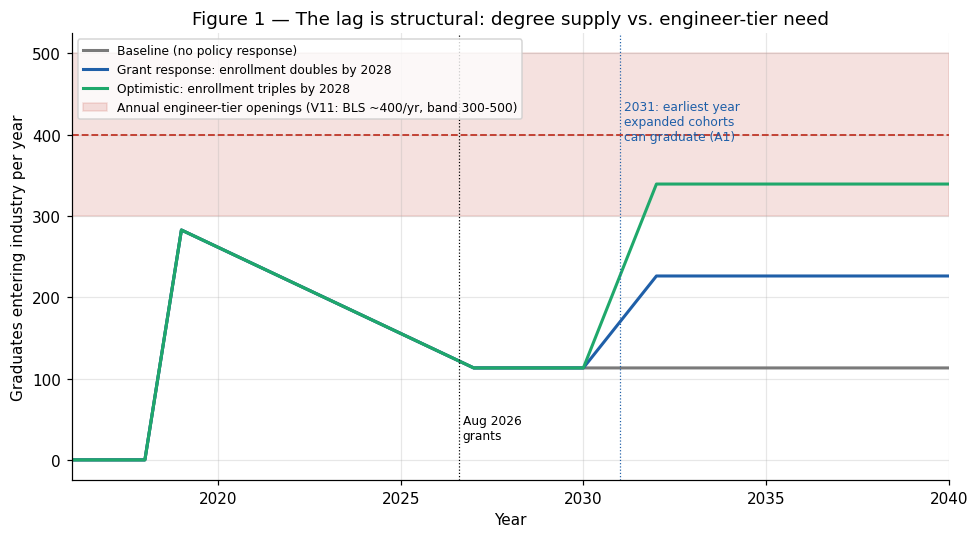

In [4]:
# ---------------- Figure 1: Engineer tier — supply vs. need ----------------
fig, ax = plt.subplots(figsize=(9, 5))
styles = {'S0_baseline': ('Baseline (no policy response)', '#7a7a7a', '-'),
          'S1_grant_doubling': ('Grant response: enrollment doubles by 2028', '#1f5fa8', '-'),
          'S2_grant_tripling': ('Optimistic: enrollment triples by 2028', '#1fa86b', '-')}
for s, (lbl, col, ls) in styles.items():
    g = graduates(enrollment_path(s)) * A['industry_entry']
    ax.plot(YEARS, g, ls, color=col, lw=2, label=lbl)
ax.axhspan(300, 500, color='#c0392b', alpha=0.15,
           label='Annual engineer-tier openings (V11: BLS ~400/yr, band 300-500)')
ax.axhline(A['eng_openings'], color='#c0392b', lw=1.2, ls='--')
ax.axvline(2026.6, color='k', lw=0.8, ls=':')
ax.text(2026.7, ax.get_ylim()[1]*0.05, 'Aug 2026\ngrants', fontsize=8)
first_gain = 2027 + A['lag']  # first year a larger cohort can graduate
ax.axvline(first_gain, color='#1f5fa8', lw=0.8, ls=':')
ax.text(first_gain + 0.1, ax.get_ylim()[1]*0.75,
        f'{first_gain}: earliest year\nexpanded cohorts\ncan graduate (A1)',
        fontsize=8, color='#1f5fa8')
ax.set(title='Figure 1 — The lag is structural: degree supply vs. engineer-tier need',
       xlabel='Year', ylabel='Graduates entering industry per year',
       xlim=(2016, 2040))
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

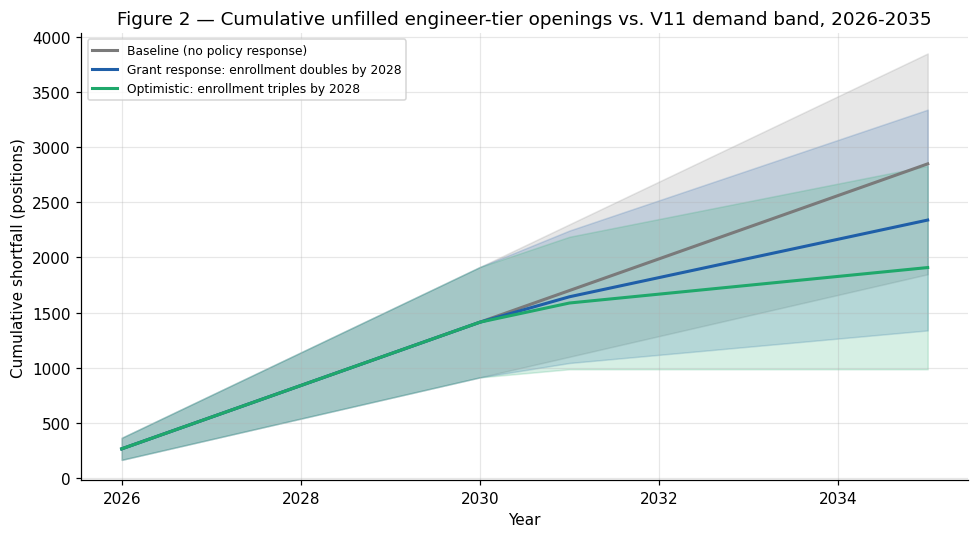

                                  scenario  cum_gap_2035_lo  cum_gap_2035_hi
             Baseline (no policy response)             1847             3847
Grant response: enrollment doubles by 2028             1338             3338
    Optimistic: enrollment triples by 2028              986             2829


In [5]:
# ---------------- Figure 2: Cumulative engineer-tier gap, 2026-2035 ----------------
w = (YEARS >= 2026) & (YEARS <= 2035)
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for s, (lbl, col, _) in styles.items():
    g = graduates(enrollment_path(s)) * A['industry_entry']
    gap_lo = np.cumsum(np.maximum(300 - g[w], 0))
    gap_hi = np.cumsum(np.maximum(500 - g[w], 0))
    ax.fill_between(YEARS[w], gap_lo, gap_hi, color=col, alpha=0.18)
    ax.plot(YEARS[w], (gap_lo + gap_hi) / 2, color=col, lw=2, label=lbl)
    rows.append(dict(scenario=lbl, cum_gap_2035_lo=int(gap_lo[-1]),
                     cum_gap_2035_hi=int(gap_hi[-1])))
ax.set(title='Figure 2 — Cumulative unfilled engineer-tier openings vs. V11 demand band, 2026-2035',
       xlabel='Year', ylabel='Cumulative shortfall (positions)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).to_string(index=False))

## 3. The practitioner tier — where the real arithmetic lives

The engineer tier is the visible gap; the practitioner tier is the decisive one. Roughly 97%
of the 11,000-13,000 annual need (V6 minus the V11 engineer tier) is technicians, operators, and skilled trades —
a population university degree programs do not serve at all. The question for this tier is
throughput: what annual training capacity, starting when, does closing it require?

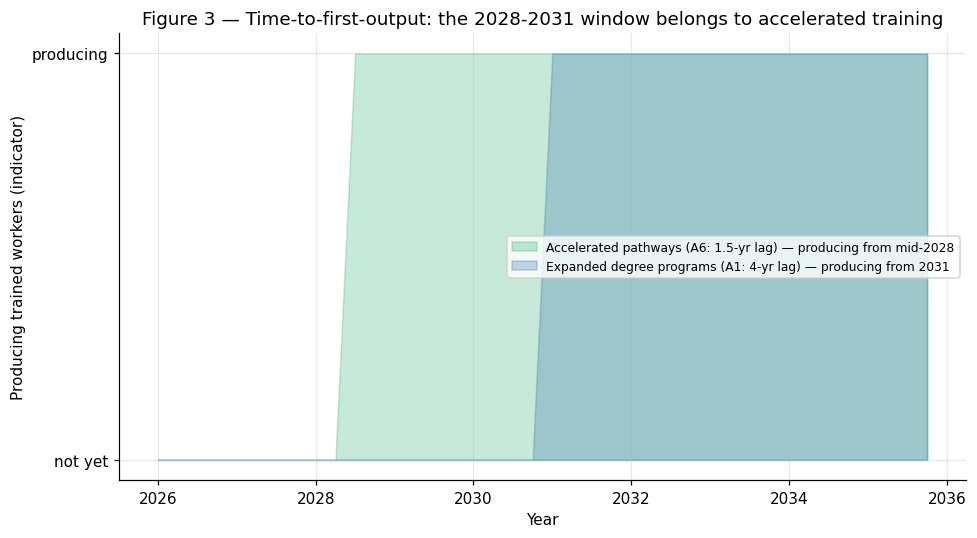

Practitioner-tier annual need (V6 minus V11): 10,600 - 12,600 per year
=> Accelerated/vocational pathways must sustain roughly that annual throughput;
   degree expansion contributes ~0 additional workers to ANY tier before 2031.


In [6]:
# ---------------- Figure 3: Time-to-impact — degrees vs. accelerated pathways ----------------
fig, ax = plt.subplots(figsize=(9, 5))
years_fine = np.arange(2026, 2036, 0.25)

def output_start(start, lag):
    return np.where(years_fine >= start + lag, 1.0, 0.0)

deg = output_start(2027, A['lag'])          # cohorts expand 2027 -> first grads 2031
acc = output_start(2027, A['accel_lag'])    # accelerated cohorts 2027 -> output mid-2028
ax.fill_between(years_fine, 0, acc, color='#1fa86b', alpha=0.25,
                label=f"Accelerated pathways (A6: {A['accel_lag']}-yr lag) — producing from mid-2028")
ax.fill_between(years_fine, 0, deg, color='#1f5fa8', alpha=0.25,
                label=f"Expanded degree programs (A1: {A['lag']}-yr lag) — producing from 2031")
ax.set(title='Figure 3 — Time-to-first-output: the 2028-2031 window belongs to accelerated training',
       xlabel='Year', ylabel='Producing trained workers (indicator)',
       yticks=[0, 1], yticklabels=['not yet', 'producing'])
ax.legend(fontsize=8, loc='center right')
plt.tight_layout(); plt.show()

# Required accelerated throughput to hold the practitioner tier level, 2028-2035
need = demand['lo']['practitioner'], demand['hi']['practitioner']
print(f"Practitioner-tier annual need (V6 minus V11): {need[0]:,.0f} - {need[1]:,.0f} per year")
print(f"=> Accelerated/vocational pathways must sustain roughly that annual throughput;")
print(f"   degree expansion contributes ~0 additional workers to ANY tier before {2027 + A['lag']}.")

In [7]:
# ---------------- Sensitivity: conclusions under assumption ranges ----------------
sens = []
for lag in [4, 5]:
    for comp in [0.60, 0.70, 0.80]:
        for need in [300, 400, 500]:
            g = graduates(enrollment_path('S1_grant_doubling'), lag=lag, completion=comp)
            g = g * A['industry_entry']
            w = (YEARS >= 2026) & (YEARS <= 2035)
            gap = np.maximum(need - g[w], 0).sum()
            sens.append(dict(lag=lag, completion=comp, eng_need_per_yr=need,
                             first_gain_year=2027 + lag,
                             cum_eng_gap_2026_2035=int(gap)))
sens = pd.DataFrame(sens)
print(sens.to_string(index=False))
print(f"\nCumulative engineer-tier gap (S1, 2026-2035) ranges "
      f"{sens.cum_eng_gap_2026_2035.min():,} - {sens.cum_eng_gap_2026_2035.max():,} "
      f"across all assumption combinations; first supply gain never precedes "
      f"{sens.first_gain_year.min()}.")
print("Note: calibration to the 2020 anchor absorbs the completion-rate parameter "
      "(identical gaps across A2 values above) -- supply level is pinned by verified "
      "data, so results are driven by lag (A1) and demand share (A4), which is exactly "
      "where the uncertainty belongs.")

 lag  completion  eng_need_per_yr  first_gain_year  cum_eng_gap_2026_2035
   4         0.6              300             2031                   1338
   4         0.6              400             2031                   2338
   4         0.6              500             2031                   3338
   4         0.7              300             2031                   1338
   4         0.7              400             2031                   2338
   4         0.7              500             2031                   3338
   4         0.8              300             2031                   1338
   4         0.8              400             2031                   2338
   4         0.8              500             2031                   3338
   5         0.6              300             2032                   1528
   5         0.6              400             2032                   2528
   5         0.6              500             2032                   3528
   5         0.7              300     

## 4. Findings (v0.2)

1. **The lag is structural and no funding level removes it.** Enrollment growth beginning in
   2027 cannot increase graduate supply before 2031 (A1). This holds across every scenario and
   every assumption combination tested. The binding constraint on the degree pipeline is time,
   not money.
2. **Even doubled enrollment leaves the engineer tier short through 2035.** Under the policy's
   own stated goal (V9), the cumulative engineer-tier shortfall from 2026-2035 runs between
   roughly 1,300 and 3,300 unfilled openings across the V11 demand band (300-500 per year),
   against BLS's central estimate of ~400 openings annually.
3. **~97% of the need is outside the university pipeline entirely.** The practitioner tier
   requires on the order of 10,600-12,600 trained workers per year (V6 minus V11) — a scale only
   accelerated, non-degree pathways (certificates, community colleges, industry upskilling,
   open training programs) can address, and the only channel that can produce output inside
   the 2028-2031 window.
4. **Policy implication.** Degree-program investment is necessary for the long run but
   arithmetically cannot be the near-term answer. The near-term answer is training
   architecture: high-throughput, short-lag practitioner pathways feeding into the same
   progression. (This is the design thesis of Project FORGE, and finding 3 is why.)

## 5. Limitations and the road to the paper

- **L0:** the enrollment (V5) and degree (V2) series are not perfectly commensurable; the
  k ≈ 1.35 calibration must be replaced by a unified ASEE/IPEDS dataset.
- A4 is now anchored to BLS OOH projected openings (V11); the journal version should add a
  demand-growth module reflecting announced processing buildout above BLS's flat baseline,
  and reconcile occupation-code coverage with the degree series.
- Demand is held flat; a demand-growth module tied to announced processing capacity
  (stockpile program, new facilities) would strengthen the result, not weaken it.
- Enrollment response to grants (A5) takes the policy goal at face value; historical
  elasticity of enrollment to funding shocks should be estimated for the journal version.
- Completion and placement rates (A2, A3) need primary sources (ASEE, SME surveys).
- The cohort model is deterministic; the paper version should add stochastic completion and
  a proper age-structured retirement module calibrated to V1.

**Publication path:** notebook (this) → Payne Institute commentary → journal manuscript
(*Resources Policy* / *Mineral Economics*), targeting co-authorship with faculty in Mineral &
Energy Economics and Operations Research.